<a href="https://colab.research.google.com/github/prathik002/DataScience-Lab/blob/main/Program_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
'''Program 16: Dataset: Iris.csv
a) Conduct exploratory data analysis on the given dataset and report the details.
b) Visualize the analysis results using (i) scatter plot (ii) histogram & (iii) box plot.
c) Implement the Decision Tree algorithm using the dataset and plot the decision tree.'''

#a) Conduct Exploratory Data Analysis (EDA)
import pandas as pd
df = pd.read_csv('/content/Iris.csv')
print(df.head())
print(df.isnull().sum())
print(df.describe())
print(df['SepalWidthCm'].value_counts())


   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.10000

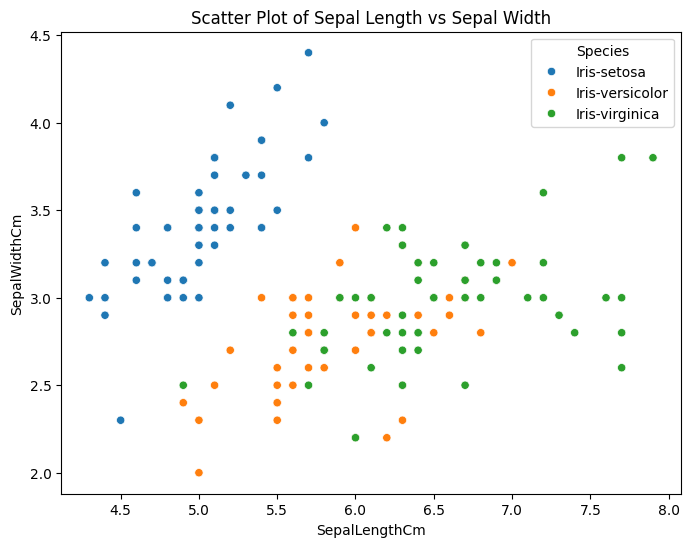

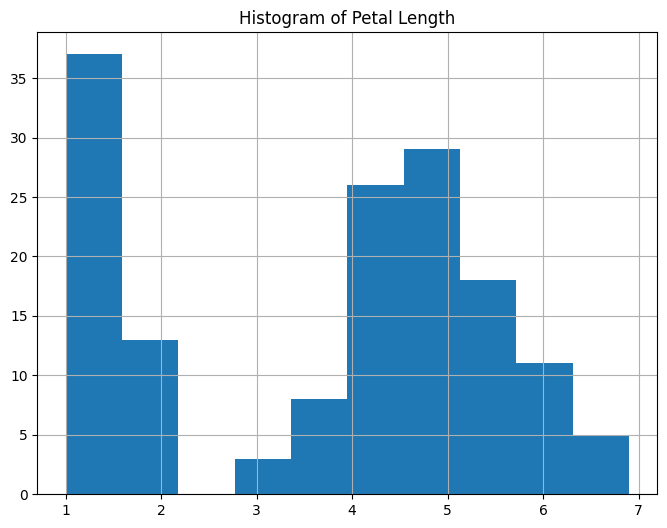

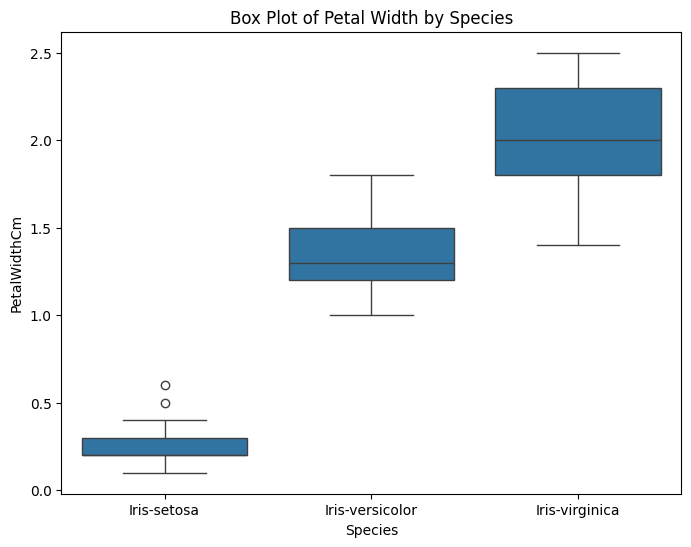

In [3]:
#b) Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

#(i) Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Species', data=df)
plt.title('Scatter Plot of Sepal Length vs Sepal Width')
plt.show()

#(ii) Histogram
plt.figure(figsize=(8,6))
df['PetalLengthCm'].hist()
plt.title('Histogram of Petal Length')
plt.show()

#(iii) Box Plot
plt.figure(figsize=(8,6))
sns.boxplot(x='Species', y='PetalWidthCm', data=df)
plt.title('Box Plot of Petal Width by Species')
plt.show()

Test Accuracy: 0.9333

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


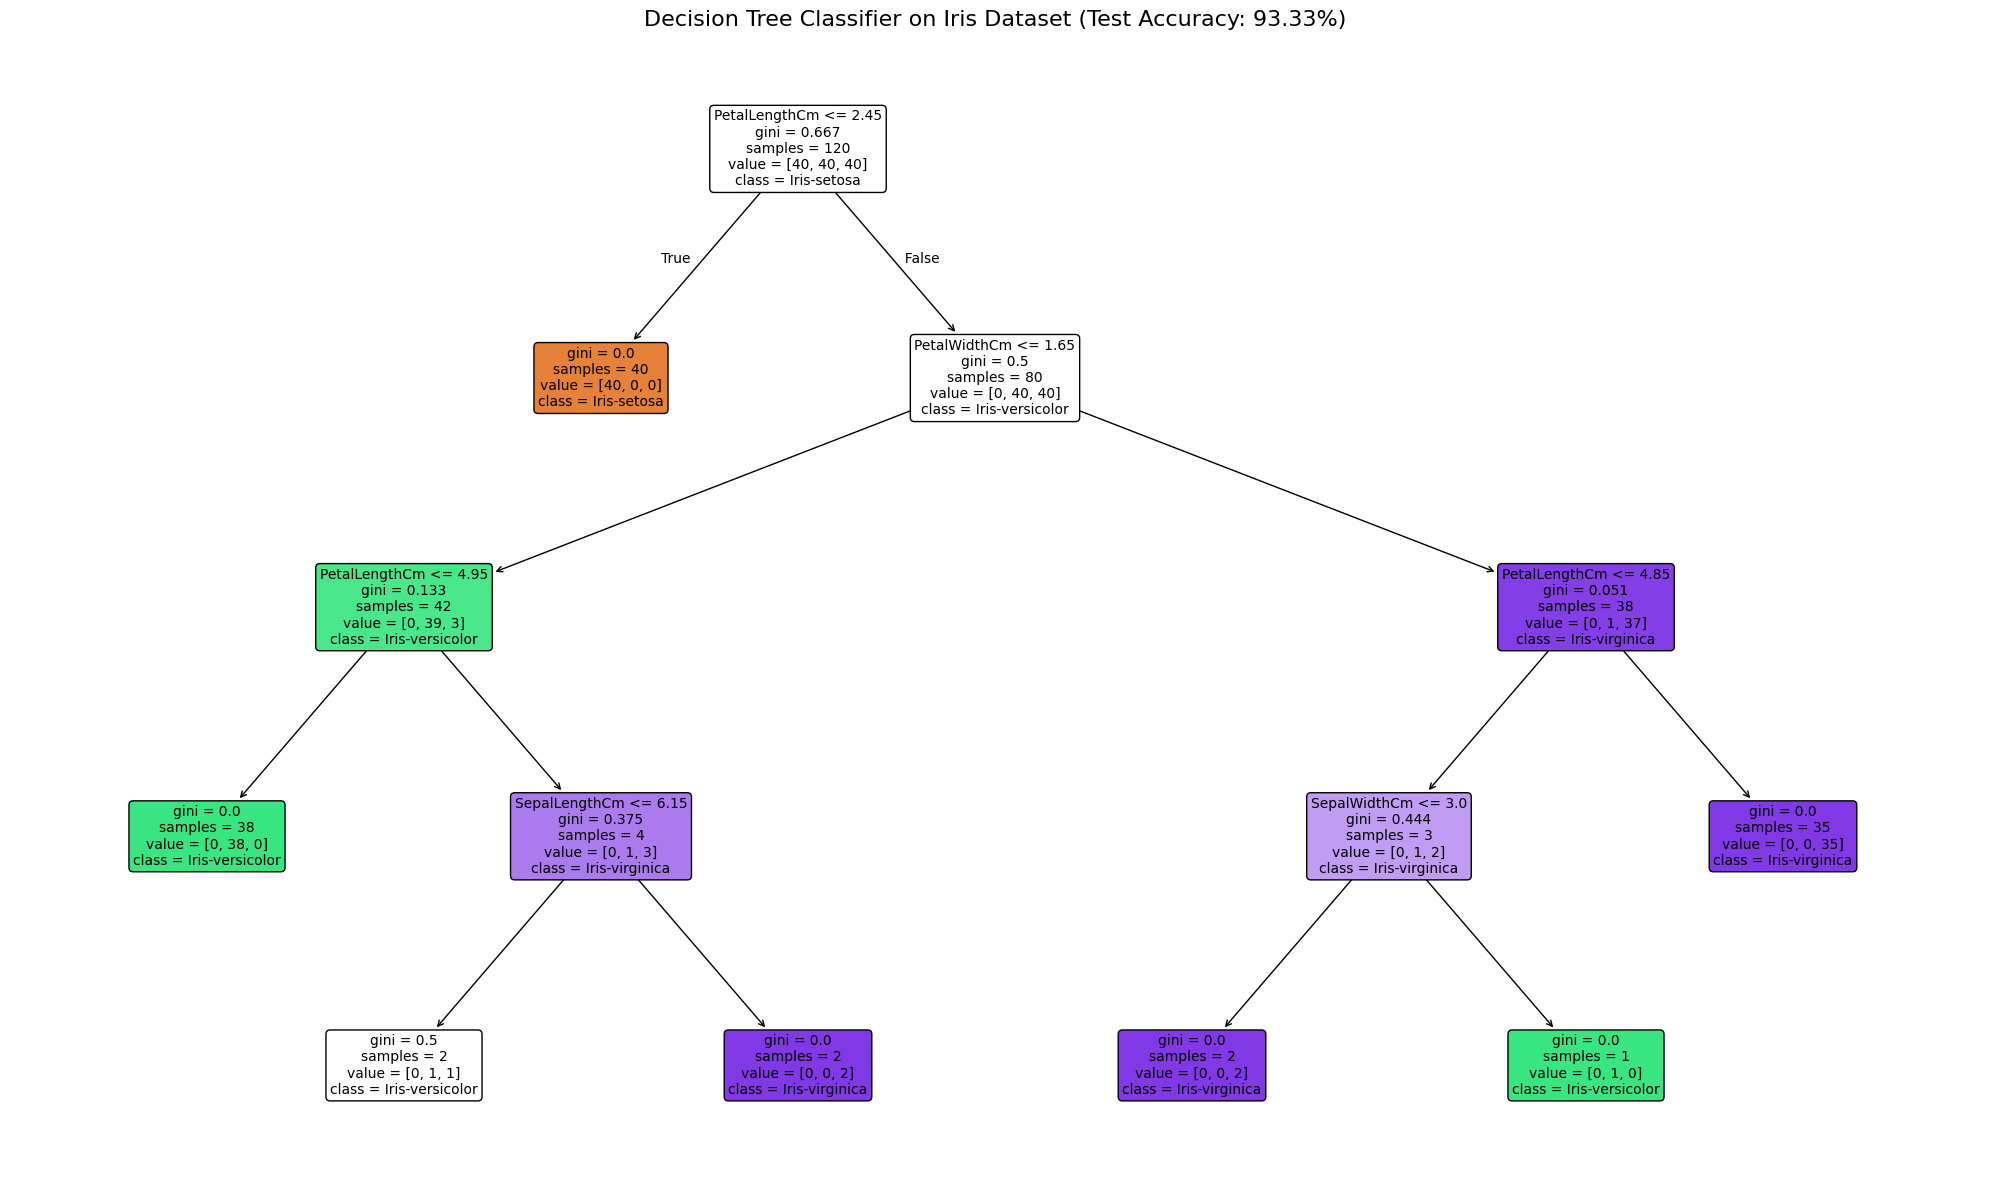


Feature Importances:
 PetalLengthCm    0.565639
PetalWidthCm     0.411154
SepalWidthCm     0.016878
SepalLengthCm    0.006329
dtype: float64

Decision tree plot saved to decision_tree_iris.png


In [7]:
#c) Decision Tree
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load data
df = pd.read_csv("Iris.csv")  # update path if your file is elsewhere

# Drop the Id column (not a feature)
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X = df[feature_cols]
y = df["Species"]

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train the Decision Tree
clf = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# 4. Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 5. Plot the Decision Tree
plt.figure(figsize=(20, 12))
plot_tree(
    clf,
    feature_names=feature_cols,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title(f"Decision Tree Classifier on Iris Dataset (Test Accuracy: {acc:.2%})", fontsize=16)
plt.tight_layout()
plt.savefig("decision_tree_iris.png", dpi=200, bbox_inches="tight")
plt.show()  # displays inline in Jupyter; remove if running as a plain script
plt.close()

# 6. Feature importance
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature Importances:\n", importances)

print("\nDecision tree plot saved to decision_tree_iris.png")